# 1. Import Libraries

In [1]:
import os
import sys
import gc
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
from scipy import stats
from sklearn.linear_model import Ridge


# 2. File Paths

In [2]:
# Menambahkan folder Scripts ke path agar model.py bisa diimport
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Path folder data
data_dir             = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir   = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
cv_output_dir        = os.path.abspath(os.path.join('..', 'Data', 'CrossValidation'))

# Buat folder CrossValidation jika belum ada
os.makedirs(cv_output_dir, exist_ok=True)

print(f"[INFO] Scripts path  : {scripts_path}")
print(f"[INFO] Data dir      : {data_dir}")
print(f"[INFO] CV output dir : {cv_output_dir}")

[INFO] Scripts path  : c:\Users\USER\Documents\Folder-Proposal\Programs\Scripts
[INFO] Data dir      : c:\Users\USER\Documents\Folder-Proposal\Programs\Data\TrainTest
[INFO] CV output dir : c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation


# 3. Import Model

In [3]:
from model import Encoder, Decoder, VAE, RSVD, KLAnnealingCallback

# 4. Load Data & Hyperparameters

## 1 Load Normalized Matrix
Cross Validation membutuhkan data **sebelum di-split** agar setiap fold
mendapat pembagian yang adil dan terkontrol. File ini disimpan di langkah
terakhir DataPreprocessing.ipynb.

In [4]:
# Load matriks rating yang sudah dinormalisasi (0-1), belum di-split
normalized_matrix_path = os.path.join(data_dir, 'normalized_matrix.npy')

try:
    normalized_matrix = np.load(normalized_matrix_path).astype(np.float32)
    num_users, num_items = normalized_matrix.shape
    print(f"[SUCCESS] Normalized matrix berhasil dimuat.")
    print(f"          Dimensi: {num_users} Users x {num_items} Items")
except FileNotFoundError:
    print("[ERROR] File 'normalized_matrix.npy' tidak ditemukan.")
    print("        Pastikan kamu sudah menjalankan DataPreprocessing.ipynb")
    print("        dan sudah menambahkan baris penyimpanan normalized_matrix.")

[SUCCESS] Normalized matrix berhasil dimuat.
          Dimensi: 943 Users x 1682 Items


## 2 Load Best Hyperparameters
Gunakan hyperparameter terbaik dari hasil tuning. Tidak perlu tuning ulang
di setiap fold karena akan sangat memakan waktu dan bukan standar akademis.

In [5]:
# Load hyperparameter terbaik VAE
vae_progress_path = os.path.join(hyperparameter_dir, 'tuning_progress_vae.json')
with open(vae_progress_path, 'r') as f:
    best_vae_params = json.load(f)['best_params']

# Load hyperparameter terbaik RSVD
rsvd_progress_path = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_path, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"[INFO] Best VAE params  : {best_vae_params}")
print(f"[INFO] Best RSVD params : {best_rsvd_params}")

[INFO] Best VAE params  : {'latent_dim': 100, 'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.1, 'beta': 0.01, 'hidden_dims': [1024, 512]}
[INFO] Best RSVD params : {'n_factors': 10, 'learning_rate': 0.005, 'lambda_reg': 0.001}


# 5. Configure Cross Validation

In [6]:
# ============================================================
# KONFIGURASI UTAMA — ubah nilai di sini jika perlu
# ============================================================

# Jumlah fold untuk K-Fold Cross Validation
N_FOLDS = 10

# Epoch untuk setiap fold (lebih sedikit dari Training final karena tujuannya konsistensi)
CV_VAE_EPOCHS  = 50
CV_RSVD_EPOCHS = 30

# Skala rating asli untuk denormalisasi hasil prediksi
MAX_RATING = 5.0

# Seed acak untuk memastikan hasil dapat direplikasi
RANDOM_SEED = 42

print(f"[INFO] Konfigurasi CV:")
print(f"       N_FOLDS        = {N_FOLDS}")
print(f"       CV_VAE_EPOCHS  = {CV_VAE_EPOCHS}")
print(f"       CV_RSVD_EPOCHS = {CV_RSVD_EPOCHS}")
print(f"       MAX_RATING     = {MAX_RATING}")
print(f"       RANDOM_SEED    = {RANDOM_SEED}")

[INFO] Konfigurasi CV:
       N_FOLDS        = 10
       CV_VAE_EPOCHS  = 50
       CV_RSVD_EPOCHS = 30
       MAX_RATING     = 5.0
       RANDOM_SEED    = 42


# 6. Create Fold Splits

## 1 All Ratings Coordinates

In [7]:
# Ambil koordinat (baris, kolom) dari semua rating yang ada nilainya (> 0)
# Ini adalah 100.000 pasang koordinat yang merepresentasikan setiap rating
all_rows, all_cols = np.nonzero(normalized_matrix)

total_ratings = len(all_rows)
print(f"[INFO] Total rating yang tersedia : {total_ratings:,}")

[INFO] Total rating yang tersedia : 100,000


## 2 Randomize and Divide into K-Fold

In [8]:
# Set seed untuk reproduksibilitas
np.random.seed(RANDOM_SEED)

# Acak urutan semua indeks rating
shuffled_indices = np.random.permutation(total_ratings)

# Bagi indeks yang sudah diacak menjadi N_FOLDS bagian yang (hampir) sama besar
# np.array_split otomatis menangani jika total tidak habis dibagi
fold_index_groups = np.array_split(shuffled_indices, N_FOLDS)

# Tampilkan ukuran setiap fold untuk verifikasi
print(f"[INFO] Pembagian {N_FOLDS} fold:")
for fold_num, fold_indices in enumerate(fold_index_groups):
    print(f"       Fold {fold_num + 1}: {len(fold_indices):,} rating sebagai data test")

[INFO] Pembagian 10 fold:
       Fold 1: 10,000 rating sebagai data test
       Fold 2: 10,000 rating sebagai data test
       Fold 3: 10,000 rating sebagai data test
       Fold 4: 10,000 rating sebagai data test
       Fold 5: 10,000 rating sebagai data test
       Fold 6: 10,000 rating sebagai data test
       Fold 7: 10,000 rating sebagai data test
       Fold 8: 10,000 rating sebagai data test
       Fold 9: 10,000 rating sebagai data test
       Fold 10: 10,000 rating sebagai data test


# 7. Helper Functions

## 1 Train/Test Matrix per Fold

In [9]:
def create_fold_matrices(normalized_matrix, all_rows, all_cols, test_fold_indices):
    """
    Membuat matriks train dan test untuk satu fold tertentu.

    Cara kerja:
    - Train matrix = normalized_matrix dengan rating test di-set ke 0
    - Test matrix  = matriks kosong yang hanya berisi rating pada fold test

    Args:
        normalized_matrix  : Matriks rating penuh (943 x 1682), sudah dinormalisasi
        all_rows           : Array semua indeks baris dari rating yang ada
        all_cols           : Array semua indeks kolom dari rating yang ada
        test_fold_indices  : Indeks dari fold_index_groups yang jadi data test fold ini

    Returns:
        train_matrix : np.ndarray (943 x 1682)
        test_matrix  : np.ndarray (943 x 1682)
        test_indices : tuple (rows, cols) koordinat test untuk filtering prediksi
    """
    # Ambil baris dan kolom koordinat untuk fold test ini
    test_rows = all_rows[test_fold_indices]
    test_cols = all_cols[test_fold_indices]

    # Buat train matrix: copy penuh, lalu hapus rating yang masuk fold test
    train_matrix = normalized_matrix.copy()
    train_matrix[test_rows, test_cols] = 0.0

    # Buat test matrix: mulai dari nol, isi hanya rating fold test
    test_matrix = np.zeros(normalized_matrix.shape, dtype=np.float32)
    test_matrix[test_rows, test_cols] = normalized_matrix[test_rows, test_cols]

    return train_matrix, test_matrix, (test_rows, test_cols)

## 2 Training VAE per Fold

In [10]:
def train_vae_fold(train_matrix, vae_params, num_items, epochs, kl_annealing_epochs=15):
    """
    Melatih VAE untuk satu fold dan mengembalikan prediksi rekonstruksi.

    Fungsi ini menggunakan KL Annealing untuk menaikkan bobot beta secara
    bertahap dari 0 ke nilai target selama kl_annealing_epochs pertama.
    Pendekatan ini mencegah posterior collapse pada ruang laten sehingga
    menghasilkan representasi yang lebih informatif.

    Fungsi ini terisolasi (semua objek model dihapus di akhir) untuk
    mencegah memory leak antar fold.

    Args:
        train_matrix        : np.ndarray matriks training fold ini
        vae_params          : dict hyperparameter terbaik VAE
        num_items           : int jumlah kolom (film) untuk dimensi output decoder
        epochs              : int jumlah epoch training untuk CV (lebih sedikit dari final)
        kl_annealing_epochs : int jumlah epoch untuk menaikkan beta dari 0 ke target.
                              Default 15 (sekitar 30% dari CV_VAE_EPOCHS=50).

    Returns:
        pred_matrix : np.ndarray hasil rekonstruksi VAE (943 x 1682), skala 0-1
    """
    # Bersihkan sesi TensorFlow sebelum membuat model baru
    tf.keras.backend.clear_session()

    # Ubah data ke TensorFlow constant agar tidak ada duplikasi memori
    train_tf = tf.constant(train_matrix, dtype=tf.float32)

    # Bangun arsitektur VAE dengan hyperparameter terbaik
    encoder = Encoder(
        hidden_dims=vae_params['hidden_dims'],
        latent_dim=vae_params['latent_dim'],
        dropout_rate=vae_params['dropout_rate']
    )
    decoder = Decoder(
        hidden_dims=vae_params['hidden_dims'][::-1],
        output_dim=num_items
    )

    # Inisialisasi VAE dengan beta=0.0 agar KL annealing mulai dari nol
    vae_model = VAE(encoder, decoder, beta=0.0)

    # Inisialisasi bobot dengan melewatkan 1 baris data
    _ = vae_model(train_tf[:1])

    # Kompilasi dengan optimizer Adam
    optimizer = tf.keras.optimizers.Adam(learning_rate=vae_params['learning_rate'])
    vae_model.compile(optimizer=optimizer, run_eagerly=True)

    # Callback KL annealing: naikkan beta dari 0 ke vae_params['beta'] secara linear
    kl_annealing = KLAnnealingCallback(
        beta_target=vae_params['beta'],
        annealing_epochs=kl_annealing_epochs
    )

    # Latih model dengan KL annealing (verbose=0 agar output tidak terlalu panjang)
    vae_model.fit(
        train_tf, train_tf,
        epochs=epochs,
        batch_size=vae_params['batch_size'],
        callbacks=[kl_annealing],
        verbose=0
    )

    # Ekstrak ruang laten (z_mean) lalu rekonstruksi dengan decoder
    z_mean, _ = vae_model.encoder.predict(train_tf, verbose=0)
    pred_matrix = vae_model.decoder.predict(z_mean, verbose=0)

    # Bersihkan semua objek model dari memori
    del encoder, decoder, vae_model, optimizer, train_tf, z_mean, _, kl_annealing
    gc.collect()
    tf.keras.backend.clear_session()

    return pred_matrix

## 3 Training RSVD per Fold

In [11]:
def train_rsvd_fold(train_matrix, rsvd_params, epochs):
    """
    Melatih RSVD untuk satu fold dan mengembalikan matriks prediksi penuh.

    Args:
        train_matrix : np.ndarray matriks training fold ini
        rsvd_params  : dict hyperparameter terbaik RSVD
        epochs       : int jumlah epoch training untuk CV

    Returns:
        pred_matrix : np.ndarray prediksi rating penuh (943 x 1682), skala 0-1
    """
    # Inisialisasi model RSVD dengan hyperparameter terbaik
    rsvd_model = RSVD(
        n_factors=rsvd_params['n_factors'],
        learning_rate=rsvd_params['learning_rate'],
        lambda_reg=rsvd_params['lambda_reg'],
        epochs=epochs
    )

    # Latih model dengan data training fold ini
    rsvd_model.fit(train_matrix)

    # Rekonstruksi prediksi penuh: bias + interaksi laten
    bias_matrix  = float(rsvd_model.mu) + rsvd_model.b_u[:, np.newaxis] + rsvd_model.b_i[np.newaxis, :]
    latent_matrix = np.dot(np.dot(rsvd_model.U, rsvd_model.Sigma), rsvd_model.V.T)
    pred_matrix  = bias_matrix + latent_matrix

    # Bersihkan objek model dari memori
    del rsvd_model, bias_matrix, latent_matrix
    gc.collect()

    return pred_matrix

## 4 Train Ridge Meta-Learner

In [12]:
def train_ridge_meta_learner(pred_vae, pred_rsvd, actual_values, alpha=1.0):
    """
    Melatih Ridge Regression sebagai meta-learner untuk menggabungkan
    prediksi VAE dan RSVD secara adaptif per rating.

    Fitur (5 fitur per rating):
    - pred_vae              : prediksi VAE
    - pred_rsvd             : prediksi RSVD
    - pred_vae^2            : kuadrat prediksi VAE (non-linearity)
    - pred_rsvd^2           : kuadrat prediksi RSVD (non-linearity)
    - pred_vae * pred_rsvd  : interaksi antara kedua prediksi

    Args:
        pred_vae      : np.ndarray prediksi VAE (sudah di-clip ke 1-5)
        pred_rsvd     : np.ndarray prediksi RSVD (sudah di-clip ke 1-5)
        actual_values : np.ndarray rating asli
        alpha         : float regularisasi Ridge (default 1.0)

    Returns:
        ridge_model : model Ridge yang sudah dilatih
    """
    # Susun matriks fitur
    X = np.column_stack([
        pred_vae,
        pred_rsvd,
        pred_vae  ** 2,
        pred_rsvd ** 2,
        pred_vae  *  pred_rsvd
    ])

    # Latih Ridge Regression
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X, actual_values)

    return ridge_model


## 5 Calculate Evaluation Metrics

In [13]:
def calculate_metrics(y_true, y_pred):
    """
    Menghitung tiga metrik evaluasi regresi sekaligus.

    Args:
        y_true : np.ndarray nilai rating asli
        y_pred : np.ndarray nilai rating yang diprediksi

    Returns:
        mse  : float Mean Squared Error
        rmse : float Root Mean Squared Error
        mae  : float Mean Absolute Error
    """
    mse  = np.mean(np.square(y_true - y_pred))
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    return mse, rmse, mae

In [14]:
# Tempat penampung hasil semua fold
cv_results = {
    'fold'       : [],
    'vae_mse'    : [], 'vae_rmse'    : [], 'vae_mae'    : [],
    'rsvd_mse'   : [], 'rsvd_rmse'   : [], 'rsvd_mae'   : [],
    'lwe_mse'    : [], 'lwe_rmse'    : [], 'lwe_mae'    : [],
    'ridge_coef' : [],  # simpan koefisien Ridge per fold untuk interpretasi
    'test_size'  : []
}

# ============================================================
# LOOP UTAMA CROSS VALIDATION
# ============================================================
for fold_idx, test_fold_indices in enumerate(fold_index_groups):
    fold_num = fold_idx + 1
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_num} / {N_FOLDS}")
    print(f"{'='*60}")

    # ----------------------------------------------------------
    # LANGKAH 1: Buat matriks train dan test untuk fold ini
    # ----------------------------------------------------------
    train_matrix, test_matrix, test_indices = create_fold_matrices(
        normalized_matrix, all_rows, all_cols, test_fold_indices
    )
    actual_values_norm = test_matrix[test_indices]
    actual_values      = actual_values_norm * MAX_RATING
    print(f"  [INFO] Train ratings: {int(np.sum(train_matrix > 0)):,} | Test ratings: {len(actual_values):,}")

    # ----------------------------------------------------------
    # LANGKAH 2: Training VAE — simpan prediksi PENUH (943 x 1682)
    # Prediksi penuh digunakan untuk:
    # - Test set  : evaluasi VAE standalone
    # - Train set : fitur untuk melatih Ridge meta-learner
    # Dengan cara ini VAE hanya dilatih SEKALI per fold
    # ----------------------------------------------------------
    print(f"  [VAE] Mulai training ({CV_VAE_EPOCHS} epoch)...")
    pred_vae_full    = train_vae_fold(train_matrix, best_vae_params, num_items, CV_VAE_EPOCHS)
    pred_vae_full_dr = np.clip(pred_vae_full * MAX_RATING, 1.0, MAX_RATING)   # denormalisasi + clip
    pred_vae_test    = pred_vae_full_dr[test_indices]
    print(f"  [VAE] Selesai.")

    # ----------------------------------------------------------
    # LANGKAH 3: Training RSVD — simpan prediksi PENUH
    # ----------------------------------------------------------
    print(f"  [RSVD] Mulai training ({CV_RSVD_EPOCHS} epoch)...")
    pred_rsvd_full    = train_rsvd_fold(train_matrix, best_rsvd_params, CV_RSVD_EPOCHS)
    pred_rsvd_full_dr = np.clip(pred_rsvd_full * MAX_RATING, 1.0, MAX_RATING)  # denormalisasi + clip
    pred_rsvd_test    = pred_rsvd_full_dr[test_indices]
    print(f"  [RSVD] Selesai.")

    # ----------------------------------------------------------
    # LANGKAH 4: Latih Ridge meta-learner pada TRAINING ratings
    # Gunakan slice dari prediksi penuh (bukan training ulang)
    # ----------------------------------------------------------
    print(f"  [LWE] Melatih Ridge meta-learner...")
    train_row_idx, train_col_idx = np.where(train_matrix > 0)
    train_indices_tuple = (train_row_idx, train_col_idx)

    # Fitur meta-learner dari prediksi di training positions
    pred_vae_train  = pred_vae_full_dr[train_indices_tuple]
    pred_rsvd_train = pred_rsvd_full_dr[train_indices_tuple]
    actual_train    = train_matrix[train_indices_tuple] * MAX_RATING

    ridge_model = train_ridge_meta_learner(pred_vae_train, pred_rsvd_train, actual_train)
    print(f"  [LWE] Koefisien Ridge : {np.round(ridge_model.coef_, 4)}")
    print(f"  [LWE] Intercept       : {ridge_model.intercept_:.4f}")

    # ----------------------------------------------------------
    # LANGKAH 5: Prediksi LWE pada test ratings
    # ----------------------------------------------------------
    X_test = np.column_stack([
        pred_vae_test,
        pred_rsvd_test,
        pred_vae_test  ** 2,
        pred_rsvd_test ** 2,
        pred_vae_test  *  pred_rsvd_test
    ])
    pred_lwe         = ridge_model.predict(X_test)
    pred_lwe_clipped = np.clip(pred_lwe, 1.0, MAX_RATING)

    # ----------------------------------------------------------
    # LANGKAH 6: Hitung metrik evaluasi
    # ----------------------------------------------------------
    mse_v,   rmse_v,   mae_v   = calculate_metrics(actual_values, pred_vae_test)
    mse_r,   rmse_r,   mae_r   = calculate_metrics(actual_values, pred_rsvd_test)
    mse_lwe, rmse_lwe, mae_lwe = calculate_metrics(actual_values, pred_lwe_clipped)

    # ----------------------------------------------------------
    # LANGKAH 7: Simpan hasil fold
    # ----------------------------------------------------------
    cv_results['fold'].append(fold_num)
    cv_results['test_size'].append(len(actual_values))
    cv_results['ridge_coef'].append(ridge_model.coef_.tolist())
    cv_results['vae_mse'].append(float(mse_v));   cv_results['vae_rmse'].append(float(rmse_v));   cv_results['vae_mae'].append(float(mae_v))
    cv_results['rsvd_mse'].append(float(mse_r));  cv_results['rsvd_rmse'].append(float(rmse_r));  cv_results['rsvd_mae'].append(float(mae_r))
    cv_results['lwe_mse'].append(float(mse_lwe)); cv_results['lwe_rmse'].append(float(rmse_lwe)); cv_results['lwe_mae'].append(float(mae_lwe))

    print(f"\n  {'Metrik':<10} | {'VAE':^12} | {'RSVD':^12} | {'LWE':^12}")
    print(f"  {'-'*10}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"  {'MSE':<10} | {mse_v:^12.4f} | {mse_r:^12.4f} | {mse_lwe:^12.4f}")
    print(f"  {'RMSE':<10} | {rmse_v:^12.4f} | {rmse_r:^12.4f} | {rmse_lwe:^12.4f}")
    print(f"  {'MAE':<10} | {mae_v:^12.4f} | {mae_r:^12.4f} | {mae_lwe:^12.4f}")

    # Bersihkan memori
    del train_matrix, test_matrix, actual_values, actual_train
    del pred_vae_full, pred_vae_full_dr, pred_vae_test, pred_vae_train
    del pred_rsvd_full, pred_rsvd_full_dr, pred_rsvd_test, pred_rsvd_train
    del pred_lwe, pred_lwe_clipped, X_test, ridge_model
    gc.collect()

print(f"\n{'='*60}")
print(f"  SEMUA FOLD SELESAI")
print(f"{'='*60}")



  FOLD 1 / 10
  [INFO] Train ratings: 90,000 | Test ratings: 10,000
  [VAE] Mulai training (50 epoch)...

  [KL Annealing] Epoch 1: beta = 0.000000 / 0.01
  [KL Annealing] Epoch 2: beta = 0.000667 / 0.01
  [KL Annealing] Epoch 3: beta = 0.001333 / 0.01
  [KL Annealing] Epoch 4: beta = 0.002000 / 0.01
  [KL Annealing] Epoch 5: beta = 0.002667 / 0.01
  [KL Annealing] Epoch 6: beta = 0.003333 / 0.01
  [KL Annealing] Epoch 7: beta = 0.004000 / 0.01
  [KL Annealing] Epoch 8: beta = 0.004667 / 0.01
  [KL Annealing] Epoch 9: beta = 0.005333 / 0.01
  [KL Annealing] Epoch 10: beta = 0.006000 / 0.01
  [KL Annealing] Epoch 11: beta = 0.006667 / 0.01
  [KL Annealing] Epoch 12: beta = 0.007333 / 0.01
  [KL Annealing] Epoch 13: beta = 0.008000 / 0.01
  [KL Annealing] Epoch 14: beta = 0.008667 / 0.01
  [KL Annealing] Epoch 15: beta = 0.009333 / 0.01
  [KL Annealing] Epoch 16: beta = 0.010000 / 0.01
  [KL Annealing] Epoch 17: beta = 0.010000 / 0.01
  [KL Annealing] Epoch 18: beta = 0.010000 / 0.01
  

# 9. Cross Validation Result

## 1 Calculate Mean and Std

In [15]:
metric_keys = [
    'vae_mse',  'vae_rmse',  'vae_mae',
    'rsvd_mse', 'rsvd_rmse', 'rsvd_mae',
    'lwe_mse',  'lwe_rmse',  'lwe_mae'
]

cv_summary = {}
for key in metric_keys:
    values = np.array(cv_results[key])
    cv_summary[key] = {
        'mean': float(np.mean(values)), 'std': float(np.std(values)),
        'min' : float(np.min(values)),  'max': float(np.max(values))
    }

print("\n" + "="*70)
print(f"RINGKASAN CROSS VALIDATION LWE — MEAN ± STD DEV ({N_FOLDS} FOLDs)")
print("="*70)
print(f"  {'Model':<10} | {'MSE':^20} | {'RMSE':^20} | {'MAE':^20}")
print(f"  {'-'*10}-+-{'-'*20}-+-{'-'*20}-+-{'-'*20}")
for model, label in [('vae','VAE'), ('rsvd','RSVD'), ('lwe','LWE')]:
    mse_str  = f"{cv_summary[f'{model}_mse']['mean']:.4f} ± {cv_summary[f'{model}_mse']['std']:.4f}"
    rmse_str = f"{cv_summary[f'{model}_rmse']['mean']:.4f} ± {cv_summary[f'{model}_rmse']['std']:.4f}"
    mae_str  = f"{cv_summary[f'{model}_mae']['mean']:.4f} ± {cv_summary[f'{model}_mae']['std']:.4f}"
    print(f"  {label:<10} | {mse_str:^20} | {rmse_str:^20} | {mae_str:^20}")
print("="*70)

# Rata-rata koefisien Ridge untuk interpretasi
coefs = np.array(cv_results['ridge_coef'])
feat_names = ['VAE', 'RSVD', 'VAE^2', 'RSVD^2', 'VAE*RSVD']
print("\n  Rata-rata koefisien Ridge per fitur:")
for name, coef in zip(feat_names, coefs.mean(axis=0)):
    print(f"    {name:<12}: {coef:.6f}")



RINGKASAN CROSS VALIDATION LWE — MEAN ± STD DEV (10 FOLDs)
  Model      |         MSE          |         RMSE         |         MAE         
  -----------+----------------------+----------------------+---------------------
  VAE        |   1.1919 ± 0.0231    |   1.0917 ± 0.0106    |   0.8423 ± 0.0069   
  RSVD       |   0.8937 ± 0.0093    |   0.9454 ± 0.0049    |   0.7446 ± 0.0033   
  LWE        |   1.2208 ± 0.0232    |   1.1049 ± 0.0105    |   0.8497 ± 0.0069   

  Rata-rata koefisien Ridge per fitur:
    VAE         : 0.847154
    RSVD        : 0.106346
    VAE^2       : 0.041303
    RSVD^2      : -0.005926
    VAE*RSVD    : -0.022038


## 2 Save to JSON

In [16]:
timestamp   = datetime.now().strftime('%Y%m%d_%H%M')
cv_run_dir  = os.path.join(cv_output_dir, f'cv_lwe_{timestamp}')
os.makedirs(cv_run_dir, exist_ok=True)

final_cv_output = {
    'timestamp'        : timestamp,
    'architecture'     : 'learned_weighted_ensemble',
    'configuration'    : {
        'n_folds'        : N_FOLDS,
        'cv_vae_epochs'  : CV_VAE_EPOCHS,
        'cv_rsvd_epochs' : CV_RSVD_EPOCHS,
        'random_seed'    : RANDOM_SEED,
        'vae_params'     : best_vae_params,
        'rsvd_params'    : best_rsvd_params,
        'ridge_alpha'    : 1.0
    },
    'per_fold_results' : cv_results,
    'summary'          : cv_summary
}

cv_json_path = os.path.join(cv_run_dir, f'cv_lwe_results_{timestamp}.json')
with open(cv_json_path, 'w') as f:
    json.dump(final_cv_output, f, indent=4)

print(f"[SUCCESS] Hasil CV LWE tersimpan di: {cv_json_path}")


[SUCCESS] Hasil CV LWE tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_lwe_20260317_2035\cv_lwe_results_20260317_2035.json


# 10. Visualization

## 1. RMSE per Fold

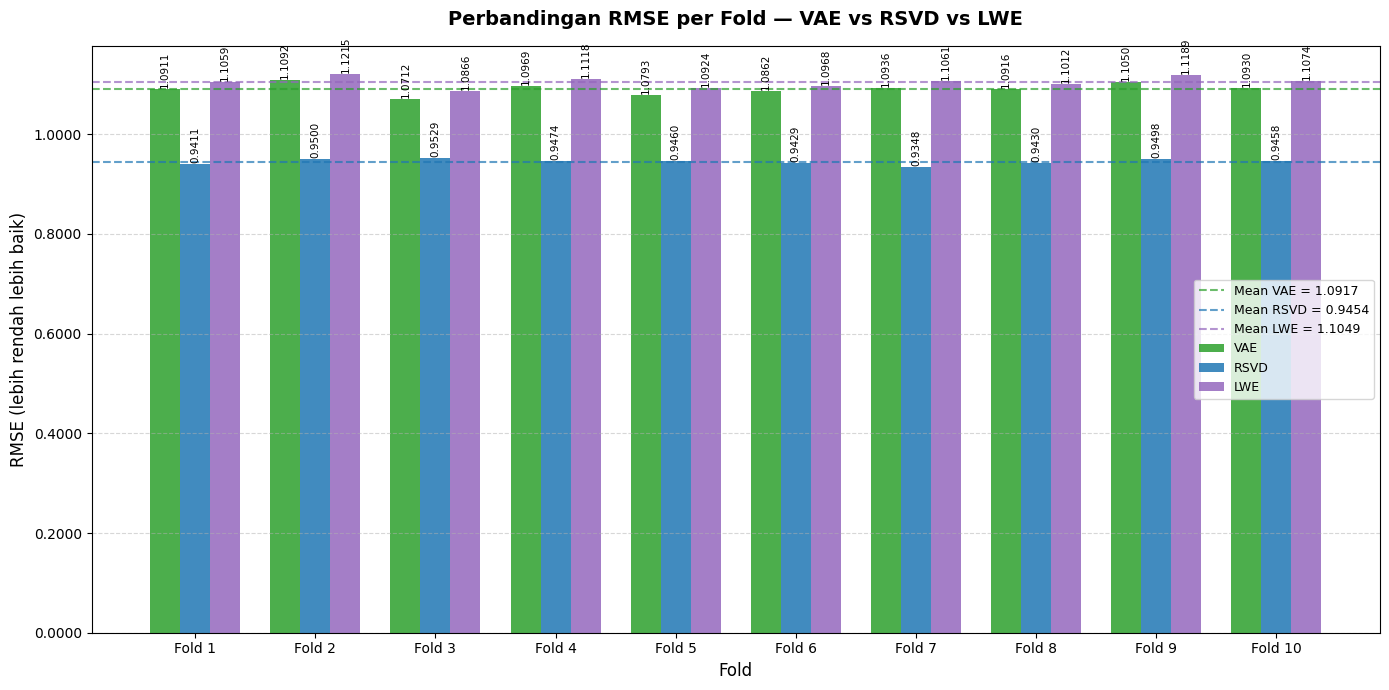

[SUCCESS] Grafik RMSE tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_lwe_20260317_2035\cv_lwe_rmse_per_fold_20260317_2035.png


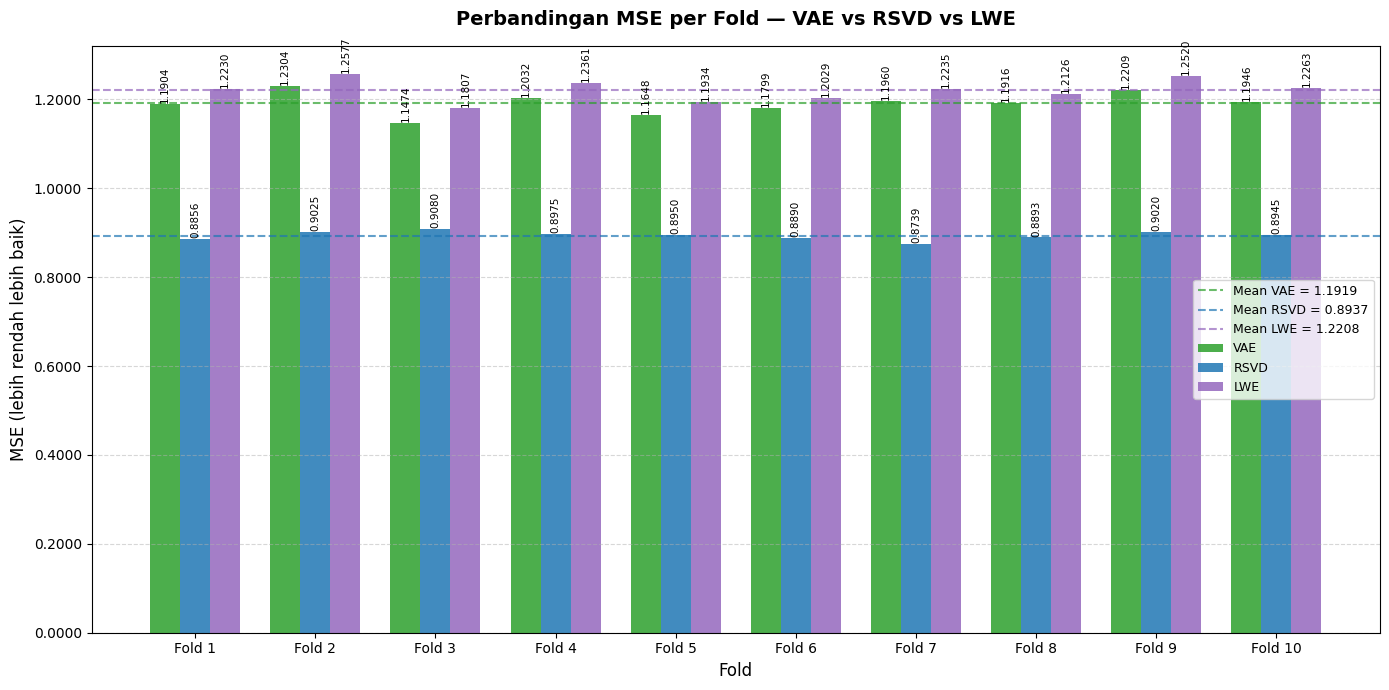

[SUCCESS] Grafik MSE tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_lwe_20260317_2035\cv_lwe_mse_per_fold_20260317_2035.png


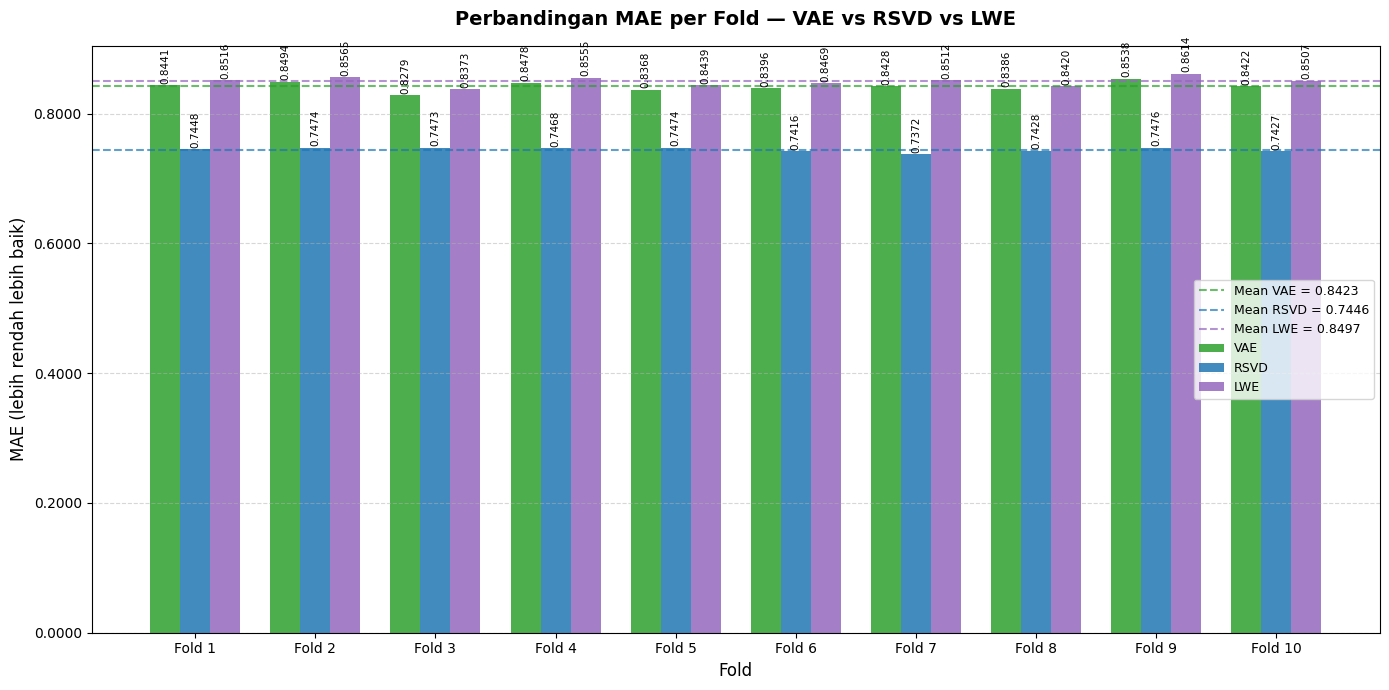

[SUCCESS] Grafik MAE tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_lwe_20260317_2035\cv_lwe_mae_per_fold_20260317_2035.png


In [17]:
fold_labels  = [f"Fold {i}" for i in cv_results['fold']]
x_positions  = np.arange(N_FOLDS)
bar_width    = 0.25

metric_bar_configs = [
    ('rmse', 'RMSE', 'cv_lwe_rmse_per_fold'),
    ('mse',  'MSE',  'cv_lwe_mse_per_fold'),
    ('mae',  'MAE',  'cv_lwe_mae_per_fold'),
]

for metric_key, metric_label, file_prefix in metric_bar_configs:
    fig, ax = plt.subplots(figsize=(14, 7), dpi=100)

    bars_vae  = ax.bar(x_positions - bar_width, cv_results[f'vae_{metric_key}'],  bar_width, label='VAE',  color='#2ca02c', alpha=0.85)
    bars_rsvd = ax.bar(x_positions,             cv_results[f'rsvd_{metric_key}'], bar_width, label='RSVD', color='#1f77b4', alpha=0.85)
    bars_lwe  = ax.bar(x_positions + bar_width, cv_results[f'lwe_{metric_key}'],  bar_width, label='LWE',  color='#9467bd', alpha=0.85)

    ax.axhline(cv_summary[f'vae_{metric_key}']['mean'],  color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean VAE = {cv_summary[f'vae_{metric_key}']['mean']:.4f}")
    ax.axhline(cv_summary[f'rsvd_{metric_key}']['mean'], color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean RSVD = {cv_summary[f'rsvd_{metric_key}']['mean']:.4f}")
    ax.axhline(cv_summary[f'lwe_{metric_key}']['mean'],  color='#9467bd', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean LWE = {cv_summary[f'lwe_{metric_key}']['mean']:.4f}")

    for bar in [*bars_vae, *bars_rsvd, *bars_lwe]:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

    ax.set_title(f'Perbandingan {metric_label} per Fold — VAE vs RSVD vs LWE', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel(f'{metric_label} (lebih rendah lebih baik)', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(fold_labels)
    ax.legend(fontsize=9, loc='center right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    plt.tight_layout()

    plot_path = os.path.join(cv_run_dir, f'{file_prefix}_{timestamp}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Grafik {metric_label} tersimpan di: {plot_path}")


# 11. Result Interpretation

In [18]:
lwe_rmse_mean  = cv_summary['lwe_rmse']['mean']
lwe_rmse_std   = cv_summary['lwe_rmse']['std']
rsvd_rmse_mean = cv_summary['rsvd_rmse']['mean']
vae_rmse_mean  = cv_summary['vae_rmse']['mean']

best_model = min(
    [('VAE', vae_rmse_mean), ('RSVD', rsvd_rmse_mean), ('LWE', lwe_rmse_mean)],
    key=lambda x: x[1]
)[0]

cv_percent = (lwe_rmse_std / lwe_rmse_mean) * 100
consistency = 'sangat konsisten' if cv_percent < 10 else ('cukup konsisten' if cv_percent < 20 else 'perlu ditinjau')

print('\n' + '='*65)
print('  INTERPRETASI HASIL CROSS VALIDATION — LWE')
print('='*65)
print(f'\n  Model terbaik berdasarkan rata-rata RMSE: {best_model}')
print(f'\n  LWE RMSE: {lwe_rmse_mean:.4f} ± {lwe_rmse_std:.4f}')
print(f'  Koefisien Variasi (CV%): {cv_percent:.2f}% → Model {consistency}')
print(f'\n  Perbandingan mean RMSE:')
print(f'    VAE  = {vae_rmse_mean:.4f}')
print(f'    RSVD = {rsvd_rmse_mean:.4f}')
print(f'    LWE  = {lwe_rmse_mean:.4f}')
print('\n  Rata-rata koefisien Ridge:')
coefs = np.array(cv_results["ridge_coef"])
for name, coef in zip(['VAE', 'RSVD', 'VAE^2', 'RSVD^2', 'VAE*RSVD'], coefs.mean(axis=0)):
    print(f'    {name:<12}: {coef:.6f}')
print('\n' + '='*65)



  INTERPRETASI HASIL CROSS VALIDATION — LWE

  Model terbaik berdasarkan rata-rata RMSE: RSVD

  LWE RMSE: 1.1049 ± 0.0105
  Koefisien Variasi (CV%): 0.95% → Model sangat konsisten

  Perbandingan mean RMSE:
    VAE  = 1.0917
    RSVD = 0.9454
    LWE  = 1.1049

  Rata-rata koefisien Ridge:
    VAE         : 0.847154
    RSVD        : 0.106346
    VAE^2       : 0.041303
    RSVD^2      : -0.005926
    VAE*RSVD    : -0.022038

